In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\Arthur Lindolpho\Documents\data_science_Alura\ML - classificacao com Sklearn\precos.csv')

In [3]:
df.head()

,milhas_por_ano,ano_do_modelo,preco,vendido
0,21801,2000,30941.02,1
1,7843,1998,40557.96,1
2,7109,2006,89627.50,0
3,26823,2015,95276.14,0
4,7935,2014,117384.68,1


In [4]:
df['km_por_ano'] = df['milhas_por_ano'] * 1.60934

In [5]:
from datetime import datetime

In [6]:
df['idade'] = df['ano_do_modelo'] = datetime.today().year - df['ano_do_modelo']

In [7]:
df.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano,idade
0,21801,26,30941.02,1,35085.22134,26
1,7843,28,40557.96,1,12622.05362,28
2,7109,20,89627.50,0,11440.79806,20
3,26823,11,95276.14,0,43167.32682,11
4,7935,12,117384.68,1,12770.11290,12


In [8]:
df = df.drop(columns=['milhas_por_ano', 'ano_do_modelo'])

In [9]:
df

,preco,vendido,km_por_ano,idade
0,30941.02,1,35085.22134,26
1,40557.96,1,12622.05362,28
2,89627.50,0,11440.79806,20
3,95276.14,0,43167.32682,11
4,117384.68,1,12770.11290,12
...,...,...,...,...
9995,97112.86,0,25060.64248,20
9996,107424.63,1,21317.31764,24
9997,93856.99,0,20950.38812,12
9998,51250.57,1,16840.13376,15


<Axes: xlabel='preco', ylabel='km_por_ano'>

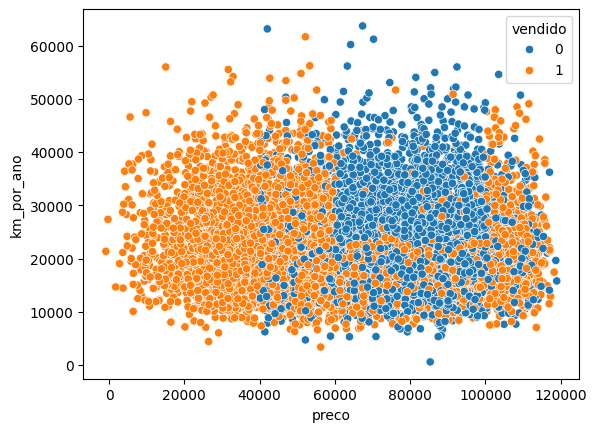

In [10]:
import seaborn as sns

sns.scatterplot(data = df, x = 'preco', y = 'km_por_ano', hue = 'vendido')

In [11]:
x = df.drop(columns='vendido')
y = df['vendido']

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

SEED = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = SEED,
                                                         stratify = y)
print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")

scaler = StandardScaler()
scaler.fit(treino_x)
treino_x_normalizado = scaler.transform(treino_x)
teste_x_normalizado = scaler.transform(teste_x)


modelo = SVC(gamma='auto')
modelo.fit(treino_x_normalizado, treino_y)
previsoes = modelo.predict(teste_x_normalizado)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {acuracia:.2f}%")

Treinaremos com 7500
Testaremos com 2500
A acurácia foi de 75.92%


## Dummy Classifier

In [13]:
from sklearn.dummy import DummyClassifier

In [14]:
dummy = DummyClassifier()
dummy.fit(treino_x, treino_y)
y_dummy_pred = dummy.predict(teste_x)

acc_dummy = accuracy_score(teste_y, y_dummy_pred)

print(f'Acurácia: {acc_dummy :.2f}')

Acurácia: 0.58


## Decision Tree e Random Forest

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree


In [21]:
df.head()

,preco,vendido,km_por_ano,idade
0,30941.02,1,35085.22134,26
1,40557.96,1,12622.05362,28
2,89627.50,0,11440.79806,20
3,95276.14,0,43167.32682,11
4,117384.68,1,12770.11290,12


In [ ]:
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = 42,
                                                         stratify = y)
print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")

scaler = StandardScaler()
scaler.fit(treino_x)
treino_x_normalizado = scaler.transform(treino_x)
teste_x_normalizado = scaler.transform(teste_x)

Treinaremos com 7500
Testaremos com 2500


In [44]:
random_forest = RandomForestClassifier(n_estimators= 10, max_depth=5)
random_forest.fit(treino_x_normalizado, treino_y)
previsao_RF = random_forest.predict(teste_x_normalizado)

acc_RF = accuracy_score(teste_y, previsao_RF)
print(f'Acurácia_RF: {acc_RF :.2f}')

Acurácia_RF: 0.77


In [56]:
arvore = DecisionTreeClassifier(criterion='gini', max_depth=3)
arvore.fit(treino_x_normalizado, treino_y)
previsao_DT = arvore.predict(teste_x_normalizado)

acc_DT = accuracy_score(teste_y, previsao_DT)
print(f'Acurácia_DT: {acc_DT}')

Acurácia_DT: 0.7804


In [37]:
import matplotlib.pyplot as plt

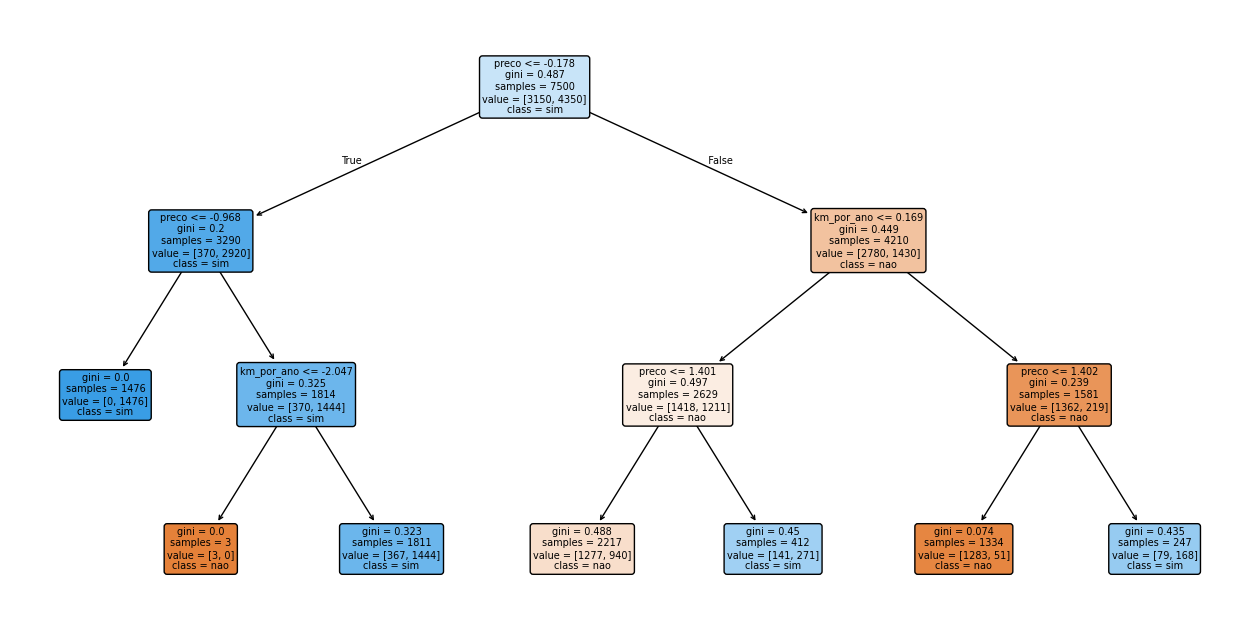

In [54]:
plt.figure(figsize = (16,8))
plot_tree(arvore, filled=True, class_names = ['nao', 'sim'], fontsize= 7, rounded= True, feature_names= x.columns)
plt.show()


### Sem a normalização dos dados

In [57]:
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = 42,
                                                         stratify = y)

In [58]:
random_forest = RandomForestClassifier(n_estimators= 10, max_depth=5)
random_forest.fit(treino_x, treino_y)
previsao_RF = random_forest.predict(teste_x)

acc_RF = accuracy_score(teste_y, previsao_RF)
print(f'Acurácia_RF: {acc_RF :.2f}')

Acurácia_RF: 0.77


In [59]:
arvore = DecisionTreeClassifier(criterion='gini', max_depth=3)
arvore.fit(treino_x, treino_y)
previsao_DT = arvore.predict(teste_x)

acc_DT = accuracy_score(teste_y, previsao_DT)
print(f'Acurácia_DT: {acc_DT}')

Acurácia_DT: 0.7804
